# DDM of uio.tif

In [1]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import scipy
from scipy.special import gamma #special function for rescaling tau
import pandas as pd
import pickle
from matplotlib.backends.backend_pdf import PdfPages



In [2]:
import numpy as np #numerical python used for working with arrays, mathematical operations
import xarray as xr #package for labeling and adding metadata to multi-dimensional arrays

In [3]:
import sys
#sys.path.append("C:\\Users\\renit\\Desktop\\PyDDM-ver2\\PyDDM") #must point to the PyDDM folder
sys.path.append("F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM") #must point to the PyDDM folder
import ddm_analysis_and_fitting as ddm

#"F:\python for ddm and sia to be saved on desktop\PyDDM-ver2"

nd2reader module not found. Reading of .nd2 files disabled.


In [4]:
#for ISF fits
import os
import xarray as xr



# Set the path to your YAML files
yaml_folder = "F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\test"
combined_pdf_path = os.path.join(yaml_folder, "all_combined_plots.pdf")
pdf = PdfPages(combined_pdf_path)

# Loop through all YAML files
for yaml_file in os.listdir(yaml_folder):
    if yaml_file.endswith('.yml') or yaml_file.endswith('.yaml'):
        yaml_path = os.path.join(yaml_folder, yaml_file)
        base_name = os.path.splitext(yaml_file)[0]
        print(f"\n🔄 Processing: {yaml_file}")

        # Step 1: Run DDM analysis
        ddm_calc_obj = ddm.DDM_Analysis(yaml_path)
        ddm_calc_obj.calculate_DDM_matrix(background_method=1, overlap_method=3)

        # Step 2: Initial Fit
        ddm_fit = ddm.DDM_Fit(ddm_calc_obj.data_yaml)
        ddm_fit.load_data(ddm_calc_obj.ddm_dataset)
        fit01 = ddm_fit.fit()
        ddm.fit_report(fit01, q_indices=[8, 12, 16, 20], forced_qs=[8, 20], use_new_tau=True, show=False)
        ddm_fit.generate_fit_report(fit_results='fit01')

        # Step 3: Final Fit using ISF - Single Exponential
        ddm_fit.reload_fit_model_by_name("ISF - Single Exponential")
        fit01b = ddm_fit.fit(display_table=False)
        ddm.fit_report(fit01b, q_indices=[5, 10, 15, 30], forced_qs=[8, 30], use_new_tau=True, show=False)

        # Step 4: Save fit report (handle figures safely)
        fit_report_pdf_path = os.path.join(yaml_folder, f"{base_name}_fit_report.pdf")
        fit_figs = [plt.figure(n) for n in plt.get_fignums()]
        with PdfPages(fit_report_pdf_path) as fit_pdf:
            for fig in fit_figs:
                fit_pdf.savefig(fig)
                pdf.savefig(fig)
                plt.close(fig)
        print(f"📄 Fit report saved: {fit_report_pdf_path}")

        # Step 5: Extract fit results (Tau vs q)
        tau = fit01b.parameters.loc['Tau'].values
        q_values = fit01b.q.values
        df = pd.DataFrame({'q': q_values, 'Tau': tau})
        df.to_csv(os.path.join(yaml_folder, f"{base_name}_fit_results.csv"), index=False)
        with open(os.path.join(yaml_folder, f"{base_name}_fit01b.pkl"), "wb") as f:
            pickle.dump(fit01b, f)

        # Step 6: Tau vs q plot
        fig_tau, ax_tau = plt.subplots(figsize=(8, 6))
        ax_tau.loglog(df['q'], df['Tau'], 'ro-', label='Tau vs q')
        ax_tau.set_xlabel(r"q ($\mu$m$^{-1}$)")
        ax_tau.set_ylabel("Decay time, Tau (s)")
        ax_tau.set_title(f"Tau vs q for {yaml_file}")
        ax_tau.legend()
        fig_path = os.path.join(yaml_folder, f"{base_name}_decay_time_vs_q.png")
        fig_tau.savefig(fig_path)
        pdf.savefig(fig_tau)
        plt.close(fig_tau)

        # Step 7: ISF vs lag time for multiple q values (in one plot)
        q_list = [1.0, 2.0, 3.0]
        fig_isf, ax_isf = plt.subplots(figsize=(8, 6))
        for q in q_list:
            q_data = ddm_calc_obj.ddm_dataset.ISF.sel(q=q, method='nearest')
            theory = fit01b.theory.sel(q=q, method='nearest')
            ax_isf.semilogx(ddm_calc_obj.ddm_dataset.lagtime, q_data, 'o', label=f"ISF q={q:.2f}")
            ax_isf.semilogx(ddm_calc_obj.ddm_dataset.lagtime, theory, 'k--', alpha=0.6)
        ax_isf.set_xlabel("Lag Time (s)")
        ax_isf.set_ylabel("ISF")
        ax_isf.set_title(f"ISF vs Lag Time for various q values ({yaml_file})")
        ax_isf.set_ylim(0.0, 1.2)
        ax_isf.legend()
        fig_path = os.path.join(yaml_folder, f"{base_name}_ISF_multiq.png")
        fig_isf.savefig(fig_path)
        pdf.savefig(fig_isf)
        plt.close(fig_isf)


       

        # Step 8: DDM matrix vs lag time for multiple q values (in one plot)
        fig_ddm, ax_ddm = plt.subplots(figsize=(8, 6))
        for q in q_list:
            ddm_vals = ddm_calc_obj.ddm_dataset.ddm_matrix.sel(q=q, method='nearest')
            theory_vals = fit01b.theory.sel(q=q, method='nearest')
            ax_ddm.semilogy(ddm_calc_obj.ddm_dataset.lagtime, ddm_vals, 'o', label=f"DDM q={q:.2f}")
            ax_ddm.semilogy(ddm_calc_obj.ddm_dataset.lagtime, theory_vals, 'k--', alpha=0.6)
        ax_ddm.set_xlabel("Lag Time (s)")
        ax_ddm.set_ylabel("DDM Matrix Value")
        ax_ddm.set_title(f"DDM Matrix vs Lag Time for various q values ({yaml_file})")
        ax_ddm.legend()
        fig_path = os.path.join(yaml_folder, f"{base_name}_DDM_multiq.png")
        fig_ddm.savefig(fig_path)
        pdf.savefig(fig_ddm)
        plt.close(fig_ddm)

# Close combined PDF
pdf.close()
print(f"\n✅ All combined plots saved to: {combined_pdf_path}")



🔄 Processing: wt15-1.yml
Provided metadata: {'pixel_size': 0.174, 'frame_rate': 5.019}
Image shape: 2000-by-256-by-256
Number of frames to use for analysis: 1999
Maximum lag time (in frames): 600
Number of lag times to compute DDM matrix: 10
The file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt15-1_ddmmatrix.nc already exists. So perhaps the DDM matrix was calculated already?


Do you still want to calculate the DDM matrix? (y/n):  n


,Initial guess,Minimum,Maximum
Amplitude,100.0,1.000,10000.0
Tau,1.0,0.001,10000.0
Background,25000.0,0.000,10000000.0
StretchingExp,1.0,0.500,1.8


Loading file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt15-1_ddmmatrix.nc ...
In function 'get_tau_vs_q_fit', using new tau...
Fit is saved in fittings dictionary with key 'fit01'.


,q,Amplitude,Tau,Background,StretchingExp
0,0.000000,100.000000,1.000000,25000.000000,1.000000
1,0.144375,10000.000000,3006.563926,37.321316,1.218398
2,0.288749,10000.000000,7099.472690,34.203894,1.122425
3,0.433124,9999.999998,3262.839526,34.752373,1.268998
4,0.577499,5119.311724,10000.000000,32.952203,0.911957
5,0.721873,8799.287868,10000.000000,33.276341,0.994176
6,0.866248,5296.983972,10000.000000,33.088504,0.913413
7,1.010623,5130.185728,10000.000000,33.069484,0.915613
8,1.154997,3587.776119,10000.000000,32.938946,0.849839
9,1.299372,2805.253721,10000.000000,33.056597,0.821519


...

In function 'get_tau_vs_q_fit', using new tau...
In hf.plot_one_tau_vs_q function, using new tau... 
In function 'get_tau_vs_q_fit', using new tau...
In hf.plot_one_tau_vs_q function, using new tau... 


,Initial guess,Minimum,Maximum
Tau,1.0,0.001,10000.0
StretchingExp,1.0,0.500,1.8


In function 'get_tau_vs_q_fit', using new tau...
Fit is saved in fittings dictionary with key 'fit02'.
In function 'get_tau_vs_q_fit', using new tau...
In hf.plot_one_tau_vs_q function, using new tau... 


C:\Users\rsaldanha\AppData\Local\Temp\ipykernel_42240\3654351332.py:38: MatplotlibDeprecationWarning: Keeping empty pdf files is deprecated since 3.8 and support will be removed in 3.10.
  with PdfPages(fit_report_pdf_path) as fit_pdf:


📄 Fit report saved: F:\python for ddm and sia to be saved on desktop\PyDDM-ver2\PyDDM\test\vn11_fit_report.pdf

✅ All combined plots saved to: F:\python for ddm and sia to be saved on desktop\PyDDM-ver2\PyDDM\test\all_combined_plots.pdf


In [6]:
import os
import matplotlib.pyplot as plt
import pandas as pd

# Assume the following variables are already defined earlier in your script:
# ddm_calc_obj: your DDMCalculator object
# fit01b: your ISF fit results object
# yaml_file: path to the YAML file
# yaml_folder: folder where YAML file is located
# base_name: base filename for outputs
# q_list: list of q values you're interested in
# pdf: matplotlib.backends.backend_pdf.PdfPages object opened for saving plots

# Step 8: DDM matrix vs lag time for multiple q values (in one plot)
fig_ddm, ax_ddm = plt.subplots(figsize=(8, 6))

# Prepare DataFrame to store all q values data
combined_df = pd.DataFrame()

for q in q_list:
    # Get DDM matrix and theoretical values for each q
    ddm_vals = ddm_calc_obj.ddm_dataset.ddm_matrix.sel(q=q, method='nearest').values
    theory_vals = fit01b.theory.sel(q=q, method='nearest').values
    lagtimes = ddm_calc_obj.ddm_dataset.lagtime.values

    # Add to plot
    ax_ddm.semilogy(lagtimes, ddm_vals, 'o', label=f"DDM q={q:.2f}")
    ax_ddm.semilogy(lagtimes, theory_vals, 'k--', alpha=0.6)

    # Append to combined DataFrame
    df_q = pd.DataFrame({
        'lagtime': lagtimes,
        f'ddm_q_{q:.2f}': ddm_vals,
        f'fit_q_{q:.2f}': theory_vals
    })
    if combined_df.empty:
        combined_df = df_q
    else:
        combined_df = pd.merge(combined_df, df_q, on='lagtime', how='outer')

# Finalize and save the plot
ax_ddm.set_xlabel("Lag Time (s)")
ax_ddm.set_ylabel("DDM Matrix Value")
ax_ddm.set_title(f"DDM Matrix vs Lag Time for various q values ({yaml_file})")
ax_ddm.legend()
fig_path = os.path.join(yaml_folder, f"{base_name}_DDM_multiq.png")
fig_ddm.savefig(fig_path)
pdf.savefig(fig_ddm)
plt.close(fig_ddm)

# Save the data points to CSV
ddm_csv_path = os.path.join(yaml_folder, f"{base_name}_DDM_fit_points.csv")
combined_df.to_csv(ddm_csv_path, index=False)
print(f"📄 DDM fit points saved: {ddm_csv_path}")


📄 DDM fit points saved: F:\python for ddm and sia to be saved on desktop\PyDDM-ver2\PyDDM\test\wt 3_DDM_fit_points.csv


We have a few options for saving the results of the fit. We can save the information contained in the xarray Dataset `fit01` as an Excel file. Or we can save it as a netCDF file using the xarray function [`to_netcdf`](https://xarray.pydata.org/en/stable/generated/xarray.Dataset.to_netcdf.html). If we have the fit results as a netCDF file, then we can reload it easily with the xarray function [`open_dataset`](https://xarray.pydata.org/en/stable/generated/xarray.open_dataset.html). 

In [59]:
#for DDM fits
import os
import xarray as xr


# Set the path to your YAML files
yaml_folder = "F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\test"
combined_pdf_path = os.path.join(yaml_folder, "all_combined_plots.pdf")
pdf = PdfPages(combined_pdf_path)

# Loop through YAML files
for yaml_file in os.listdir(yaml_folder):
    if yaml_file.endswith('.yml') or yaml_file.endswith('.yaml'):
        yaml_path = os.path.join(yaml_folder, yaml_file)
        base_name = os.path.splitext(yaml_file)[0]
        print(f"\n🔄 Processing: {yaml_file}")

        # Create output folder
        output_dir = os.path.join(yaml_folder, f"{base_name}_individual_plots")
        os.makedirs(output_dir, exist_ok=True)

        # Step 1: Run DDM analysis
        ddm_analysis = ddm.DDM_Analysis(yaml_path)
        ddm_analysis.calculate_DDM_matrix(background_method=1, overlap_method=3)

        # Step 2: Fit using "DDM Matrix - Single Exponential"
        ddm_fitter = ddm.DDM_Fit(ddm_analysis.data_yaml)
        ddm_fitter.load_data(ddm_analysis.ddm_dataset)
        ddm_fitter.reload_fit_model_by_name("DDM Matrix - Single Exponential")
        ddm_fit_result = ddm_fitter.fit(use_new_tau=True, display_table=False)
        ddm.fit_report(ddm_fit_result, q_indices=[5, 10, 15, 30], forced_qs=[8, 30], use_new_tau=True, show=False)

        # Step 3: Save fit report figures
        fit_figures = [plt.figure(n) for n in plt.get_fignums()]
        report_pdf_path = os.path.join(yaml_folder, f"{base_name}_fit_report.pdf")
        with PdfPages(report_pdf_path) as report_pdf:
            for i, fig in enumerate(fit_figures):
                fig_path = os.path.join(output_dir, f"{base_name}_fit_plot_{i+1}.png")
                fig.savefig(fig_path)
                report_pdf.savefig(fig)
                pdf.savefig(fig)
                plt.close(fig)
        print(f"📄 Fit report saved: {report_pdf_path}")

        # Step 4: Save Tau vs q as CSV and pickle
        tau = ddm_fit_result.parameters.loc['Tau'].values
        q_values = ddm_fit_result.q.values
        df_tau_q = pd.DataFrame({'q': q_values, 'Tau': tau})
        df_tau_q.to_csv(os.path.join(yaml_folder, f"{base_name}_tau_vs_q.csv"), index=False)
        with open(os.path.join(yaml_folder, f"{base_name}_fit_result.pkl"), "wb") as f:
            pickle.dump(ddm_fit_result, f)

        # Step 5: Plot Tau vs q
        fig_tau, ax_tau = plt.subplots(figsize=(8, 6))
        ax_tau.loglog(df_tau_q['q'], df_tau_q['Tau'], 'ro-', label='Tau vs q')
        ax_tau.set_xlabel(r"q ($\mu$m$^{-1}$)")
        ax_tau.set_ylabel("Decay time, Tau (s)")
        ax_tau.set_title(f"Tau vs q for {yaml_file}")
        ax_tau.legend()
        fig_tau_path = os.path.join(yaml_folder, f"{base_name}_tau_vs_q.png")
        fig_tau.savefig(fig_tau_path)
        pdf.savefig(fig_tau)
        plt.close(fig_tau)

        # Step 6: DDM matrix vs lag time (individual and combined)
        q_list = [1.0, 2.0, 3.0]
        fig_ddm_all, ax_ddm_all = plt.subplots(figsize=(8, 6))
        for q in q_list:
            lagtime = ddm_analysis.ddm_dataset.lagtime
            ddm_raw = ddm_analysis.ddm_dataset.ddm_matrix.sel(q=q, method='nearest')
            tau_q = ddm_fit_result.parameters.loc['Tau'].sel(q=q, method='nearest').values
            amp_q = ddm_fit_result.parameters.loc['Amplitude'].sel(q=q, method='nearest').values
            bkg_q = ddm_fit_result.parameters.loc['Background'].sel(q=q, method='nearest').values
            ddm_model = amp_q * (1 - np.exp(-lagtime / tau_q)) + bkg_q

            # Individual plot
            fig_i, ax_i = plt.subplots()
            ax_i.plot(lagtime, ddm_raw, 'o', label='DDM Data')
            ax_i.plot(lagtime, ddm_model, 'k--', label='Fit')
            ax_i.set_xscale('log')
            ax_i.set_xlabel("Lag Time (s)")
            ax_i.set_ylabel("DDM Matrix Value")
            ax_i.set_title(f"DDM Matrix at q = {q:.2f} μm⁻¹")
            ax_i.legend()
            fig_i_path = os.path.join(output_dir, f"{base_name}_DDM_q{int(q*10)}.png")
            fig_i.savefig(fig_i_path)
            plt.close(fig_i)

            # Add to combined plot
            ax_ddm_all.plot(lagtime, ddm_raw, 'o', label=f"q={q:.2f}")
            ax_ddm_all.plot(lagtime, ddm_model, 'k--', alpha=0.6)
        ax_ddm_all.set_xlabel("Lag Time (s)")
        ax_ddm_all.set_ylabel("DDM Matrix Value")
        ax_ddm_all.set_xscale('log')
        ax_ddm_all.set_title(f"DDM Matrix vs Lag Time ({yaml_file})")
        ax_ddm_all.legend()
        fig_all_path = os.path.join(yaml_folder, f"{base_name}_DDM_multiq.png")
        fig_ddm_all.savefig(fig_all_path)
        pdf.savefig(fig_ddm_all)
        plt.close(fig_ddm_all)

# Finalize combined PDF
pdf.close()
print(f"\n✅ All plots saved to: {combined_pdf_path}")



🔄 Processing: wt 3.yml
Provided metadata: {'pixel_size': 0.174, 'frame_rate': 5.019}
Image shape: 2000-by-256-by-256
Number of frames to use for analysis: 1999
Maximum lag time (in frames): 600
Number of lag times to compute DDM matrix: 10
The file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt 3_ddmmatrix.nc already exists. So perhaps the DDM matrix was calculated already?


Do you still want to calculate the DDM matrix? (y/n):  n


,Initial guess,Minimum,Maximum
Amplitude,100.0,1.000,10000.0
Tau,1.0,0.001,10000.0
Background,25000.0,0.000,10000000.0
StretchingExp,1.0,0.500,1.8


Loading file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt 3_ddmmatrix.nc ...


,Initial guess,Minimum,Maximum
Amplitude,100.0,1.000,10000.0
Tau,1.0,0.001,10000.0
Background,25000.0,0.000,10000000.0
StretchingExp,1.0,0.500,1.8


TypeError: DDM_Fit.fit() got an unexpected keyword argument 'use_new_tau'

Provided metadata: {'pixel_size': 0.174, 'frame_rate': 5.019}
Image shape: 2000-by-256-by-256
Number of frames to use for analysis: 1999
Maximum lag time (in frames): 600
Number of lag times to compute DDM matrix: 10
The file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt 3_ddmmatrix.nc already exists. So perhaps the DDM matrix was calculated already?


Do you still want to calculate the DDM matrix? (y/n):  n


,Initial guess,Minimum,Maximum
Amplitude,100.0,1.000,10000.0
Tau,1.0,0.001,10000.0
Background,25000.0,0.000,10000000.0
StretchingExp,1.0,0.500,1.8


Loading file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt 3_ddmmatrix.nc ...
In function 'get_tau_vs_q_fit', using new tau...
Fit is saved in fittings dictionary with key 'fit01'.


,q,Amplitude,Tau,Background,StretchingExp
0,0.000000,1.000000,9999.999998,0.000042,1.800000
1,0.141056,10000.000000,1412.199534,21.634397,1.540040
2,0.282111,9999.999990,9245.318507,22.637778,1.135071
3,0.423167,5147.804830,10000.000000,23.706864,0.966573
4,0.564223,313.711920,287.204665,25.026906,1.087561
5,0.705279,735.580628,784.525592,24.455037,1.020676
6,0.846334,9999.999996,7733.757095,25.504850,1.105575
7,0.987390,9999.999998,5285.542633,25.557479,1.202026
8,1.128446,8961.005114,10000.000000,25.375821,1.052482
9,1.269501,522.284722,771.447668,25.342646,0.983437


,Initial guess,Minimum,Maximum
Tau,1.0,0.001,10000.0
StretchingExp,1.0,0.500,1.8


In function 'get_tau_vs_q_fit', using new tau...
Fit is saved in fittings dictionary with key 'fit02'.
Fit results saved for wt 3.yml as F:\python for ddm and sia to be saved on desktop\PyDDM-ver2\PyDDM\test\wt 3_fit_results.csv


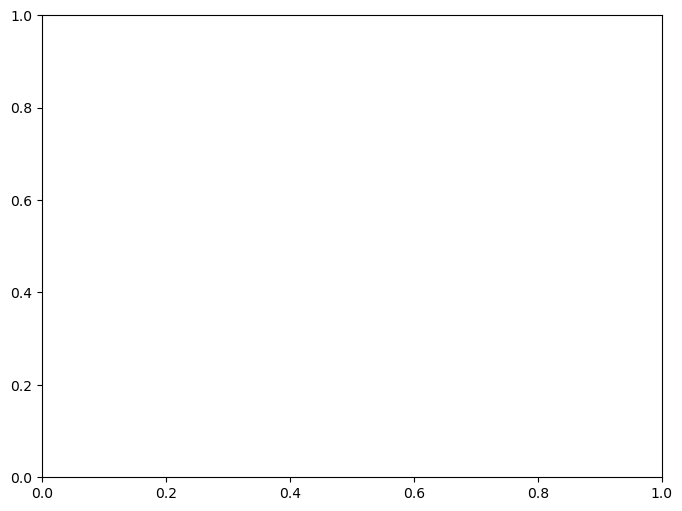

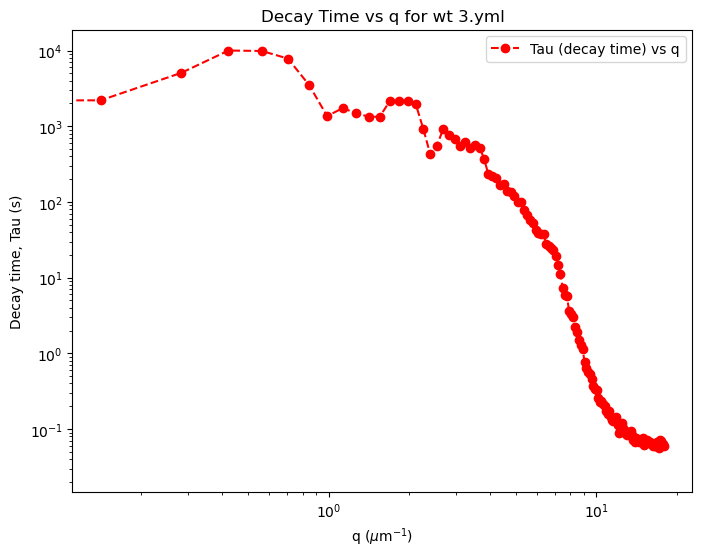

Decay time vs q plot saved as F:\python for ddm and sia to be saved on desktop\PyDDM-ver2\PyDDM\test\wt 3_decay_time_vs_q.png


ValueError: x and y must have same first dimension, but have shapes (10,) and (128,)

In [68]:
import os
import xarray as xr


# Define folder path where YAML files are stored
yaml_folder = "F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\test"

# List of q indices to plot for ISF and DDM matrix vs lag time
selected_q_indices = [5, 10, 15, 30]

# Loop through each YAML file in the folder
for yaml_file in os.listdir(yaml_folder):
    if yaml_file.endswith('.yml') or yaml_file.endswith('.yaml'):
        yaml_path = os.path.join(yaml_folder, yaml_file)

        # Step 1: Initialize DDM analysis with the current YAML file
        ddm_calc = ddm.DDM_Analysis(yaml_path)

        # Step 2: Calculate the DDM matrix
        ddm_calc.calculate_DDM_matrix(background_method=1, overlap_method=3)

        # Step 3: Perform the initial fit
        ddm_fit = ddm.DDM_Fit(ddm_calc.data_yaml)
        fit01 = ddm_fit.fit()

        # Step 4: Reload the fit model and fit again
        ddm_fit.reload_fit_model_by_name("ISF - Single Exponential")
        fit01b = ddm_fit.fit(display_table=False)

        # Step 5: Extract fit results and save as CSV
        try:
            tau = fit01b.parameters.loc['Tau'].values
            q_values = fit01b.q.values
            result_df = pd.DataFrame({"q": q_values, "Tau": tau})
            csv_filename = os.path.splitext(yaml_file)[0] + "_fit_results.csv"
            csv_filepath = os.path.join(yaml_folder, csv_filename)
            result_df.to_csv(csv_filepath, index=False)
            print(f"Fit results saved for {yaml_file} as {csv_filepath}")
        except Exception as e:
            print(f"Error extracting parameters from {yaml_file}: {e}")
            continue

        # Step 6: Plot Tau vs q
        fig, ax = plt.subplots(figsize=(8, 6))
        ax.loglog(q_values, tau, 'ro--', label='Tau (decay time) vs q')  # dotted line
        ax.set_xlabel("q ($\\mu$m$^{-1}$)")
        ax.set_ylabel("Decay time, Tau (s)")
        ax.set_title(f"Decay Time vs q for {yaml_file}")
        ax.legend()
        plot_filename = os.path.splitext(yaml_file)[0] + "_decay_time_vs_q.png"
        plot_filepath = os.path.join(yaml_folder, plot_filename)
        plt.savefig(plot_filepath)
        plt.show()
        plt.close(fig)

        print(f"Decay time vs q plot saved as {plot_filepath}")

        # Step 7: Plot DDM matrix vs lag time for selected q values
        fig, ax = plt.subplots(figsize=(8, 6))
        for idx in selected_q_indices:
            q_val = fit01b.q[idx]
            lag_times = fit01b.lagtime
            ddm_vals = fit01b.ddm_matrix_data[idx, :]
            ax.loglog(lag_times, ddm_vals, linestyle='--', label=f"q = {q_val:.2f}")
        ax.set_xlabel("Lag Time (s)")
        ax.set_ylabel("DDM Matrix")
        ax.set_title(f"DDM Matrix vs Lag Time for {yaml_file}")
        ax.legend()
        matrix_plot_filename = os.path.splitext(yaml_file)[0] + "_DDM_matrix_vs_lagtime.png"
        matrix_plot_filepath = os.path.join(yaml_folder, matrix_plot_filename)
        plt.savefig(matrix_plot_filepath)
        plt.show()
        plt.close(fig)
        print(f"DDM matrix plot saved as {matrix_plot_filepath}")

        # Step 8: Plot ISF vs lag time for same q values
        fig, ax = plt.subplots(figsize=(8, 6))
        for idx in selected_q_indices:
            q_val = fit01b.q[idx]
            lag_times = fit01b.lagtime
            isf_vals = fit01b.isf_data[idx, :]
            ax.semilogx(lag_times, isf_vals, linestyle='--', label=f"q = {q_val:.2f}")
        ax.set_xlabel("Lag Time (s)")
        ax.set_ylabel("ISF")
        ax.set_title(f"ISF vs Lag Time for {yaml_file}")
        ax.legend()
        isf_plot_filename = os.path.splitext(yaml_file)[0] + "_ISF_vs_lagtime.png"
        isf_plot_filepath = os.path.join(yaml_folder, isf_plot_filename)
        plt.savefig(isf_plot_filepath)
        plt.show()
        plt.close(fig)
        print(f"ISF plot saved as {isf_plot_filepath}")


In [ ]:
import os

import xarray as xr

# Define folder containing .yaml files
yaml_folder = "F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\test"
selected_q_indices = [5, 10, 15, 20]  # Q indices to use for plots

# Loop through each YAML file
for yaml_file in os.listdir(yaml_folder):
    if yaml_file.endswith('.yml') or yaml_file.endswith('.yaml'):
        yaml_path = os.path.join(yaml_folder, yaml_file)
        print(f"Processing: {yaml_file}")

        try:
            # Step 1: Run DDM analysis
            ddm_calc = ddm.DDM_Analysis(yaml_path)
            ddm_calc.calculate_DDM_matrix(background_method=1, overlap_method=3)

            # Step 2: Perform DDM fit
            ddm_fit = ddm.DDM_Fit(ddm_calc.data_yaml)
            fit01 = ddm_fit.fit()
            ddm_fit.reload_fit_model_by_name("ISF - Single Exponential")
            fit01b = ddm_fit.fit(display_table=False)

            # Step 3: Extract fit results
            tau = fit01b.parameters.loc['Tau'].values
            q_values = fit01b.q.values
            lag_times = fit01b.lag_times
            lag_times_fit = fit01b.lag_times_fit
            ISF_model = fit01b.model_ISF  # Shape: (q, lag_times_fit)
            DDM_matrix = ddm_calc.DDM_matrix  # Shape: (q, lag_times)

            # Step 4: Save fit results as CSV
            result_df = pd.DataFrame({"q": q_values, "Tau": tau})
            csv_filename = os.path.splitext(yaml_file)[0] + "_fit_results.csv"
            result_df.to_csv(os.path.join(yaml_folder, csv_filename), index=False)

            # Step 5: Plot Tau vs q
            fig1, ax1 = plt.subplots(figsize=(8, 6))
            ax1.loglog(q_values, tau, 'ro-', label='Tau (decay time) vs q')
            ax1.set_xlabel("q ($\\mu$m$^{-1}$)")
            ax1.set_ylabel("Decay time, Tau (s)")
            ax1.set_title(f"Decay Time vs q: {yaml_file}")
            ax1.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(yaml_folder, os.path.splitext(yaml_file)[0] + "_decay_time_vs_q.png"))
            plt.close()

            # Step 6: Plot DDM matrix vs lag time for selected q indices
            fig2, ax2 = plt.subplots(figsize=(8, 6))
            for idx in selected_q_indices:
                if idx < len(q_values):
                    ax2.semilogx(lag_times, DDM_matrix[idx], label=f'q = {q_values[idx]:.2f}')
            ax2.set_xlabel("Lag Time (s)")
            ax2.set_ylabel("DDM Matrix")
            ax2.set_title(f"DDM Matrix vs Lag Time: {yaml_file}")
            ax2.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(yaml_folder, os.path.splitext(yaml_file)[0] + "_DDM_matrix_vs_lagtime.png"))
            plt.close()

            # Step 7: Plot ISF model vs lag time with dotted lines for selected q indices
            fig3, ax3 = plt.subplots(figsize=(8, 6))
            for idx in selected_q_indices:
                if idx < len(q_values):
                    ax3.semilogx(lag_times_fit, ISF_model[idx], linestyle='--', label=f'q = {q_values[idx]:.2f}')
            ax3.set_xlabel("Lag Time (s)")
            ax3.set_ylabel("Intermediate Scattering Function (ISF)")
            ax3.set_title(f"ISF Fit vs Lag Time: {yaml_file}")
            ax3.legend()
            plt.tight_layout()
            plt.savefig(os.path.join(yaml_folder, os.path.splitext(yaml_file)[0] + "_ISF_fit_vs_lagtime.png"))
            plt.close()

            print(f"Plots and fit results saved for {yaml_file}\n")

        except Exception as e:
            print(f"Error processing {yaml_file}: {e}")


Processing: wt13-3.yml
Provided metadata: {'pixel_size': 0.174, 'frame_rate': 5.019}
Image shape: 2000-by-256-by-256
Number of frames to use for analysis: 1999
Maximum lag time (in frames): 600
Number of lag times to compute DDM matrix: 10
Unable to get DDM matrix.
Error processing wt13-3.yml: 'DDM_Analysis' object has no attribute 'ddm_dataset'
Processing: wt 3.yml
Provided metadata: {'pixel_size': 0.174, 'frame_rate': 5.019}
Image shape: 2000-by-256-by-256
Number of frames to use for analysis: 1999
Maximum lag time (in frames): 600
Number of lag times to compute DDM matrix: 10
The file F:\\python for ddm and sia to be saved on desktop\\PyDDM-ver2\\PyDDM\\wt 3_ddmmatrix.nc already exists. So perhaps the DDM matrix was calculated already?
